# Topt_ave Regression — TEMPURA

**計画書:** [`../docs/modeling_plan_ja.md`](../docs/modeling_plan_ja.md)
**サマリー:** [`../docs/executive_summary_ja.md`](../docs/executive_summary_ja.md)

本ノートは、原核生物 8,639 株の **最適生育温度 `Topt_ave`** を
`Tmin` / `Tmax` / GC 含量 / 分類情報から予測する回帰モデルを学習する。

計画書に従い:

1. 5-fold `StratifiedKFold`（`superkingdom` で層化）
2. Dummy / Ridge / HistGradientBoosting を比較
3. 全体 + superkingdom 別 + 温度カテゴリ別に MAE / RMSE / R² を報告

の手順で進める。

## 1. セットアップ

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')
RNG = 42

## 2. データ読み込み + 派生カラム

- `temp_cat` は EDA と同じ 4 カテゴリ（好冷/中温/好熱/超好熱）。
- `phylum_grouped` は出現率 ≥ 1% の門だけ残し、それ以外は `Other` にまとめる。

In [2]:
df = pd.read_csv('../data/raw/tempura.csv')

def temp_category(t):
    if t < 20:  return 'Psychrophile'
    if t < 45:  return 'Mesophile'
    if t < 80:  return 'Thermophile'
    return 'Hyperthermophile'
df['temp_cat'] = df['Topt_ave'].apply(temp_category)

phylum_counts = df['phylum'].value_counts(normalize=True)
top_phyla = phylum_counts[phylum_counts >= 0.01].index.tolist()
df['phylum_grouped'] = np.where(df['phylum'].isin(top_phyla), df['phylum'], 'Other')
df['phylum_grouped'] = df['phylum_grouped'].fillna('Unknown')

print(f"Rows : {len(df):,}")
print(f"Kept phyla (≥1%): {len(top_phyla)}")
print(df['phylum_grouped'].value_counts().head(10))

Rows : 8,639
Kept phyla (≥1%): 5
phylum_grouped
Proteobacteria    3109
Firmicutes        1572
Actinobacteria    1485
Bacteroidetes     1422
Other              582
Euryarchaeota      469
Name: count, dtype: int64


## 3. 特徴量 / 目的変数の定義

In [3]:
NUMERIC_FEATURES = ['Tmin', 'Tmax', 'Tmax_Tmin', '16S_GC', 'Genome_GC']
CATEGORICAL_FEATURES = ['superkingdom', 'phylum_grouped']

X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].copy()
y = df['Topt_ave'].values
strata = df['superkingdom'].values  # 層化に使用

print(X.shape, y.shape)
print(X.head())

(8639, 7) (8639,)
   Tmin   Tmax  Tmax_Tmin  16S_GC  Genome_GC superkingdom phylum_grouped
0  85.0  122.0       37.0    67.7        NaN      Archaea  Euryarchaeota
1  85.0  121.0       36.0     NaN        NaN      Archaea          Other
2  90.0  113.0       23.0    68.4       54.9      Archaea          Other
3  70.0  112.0       42.0    66.5       44.6      Archaea  Euryarchaeota
4  84.0  110.0       38.0    68.1       61.2      Archaea  Euryarchaeota


## 4. 前処理パイプライン

- 数値: 中央値補完 → 標準化
- カテゴリ: `Unknown` 補完 → One-Hot（未知カテゴリは無視）

In [4]:
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_FEATURES),
    ('cat', categorical_pipe, CATEGORICAL_FEATURES),
])
preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Tmin', 'Tmax', 'Tmax_Tmin', '16S_GC',
                                  'Genome_GC']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['superkingdom', 'phylum_grouped'])])

## 5. 共通の CV 定義（superkingdom 層化）

`StratifiedKFold` は **連続値の目的変数に対しては層化できない** ため、
`superkingdom`（カテゴリカル）を層化キーとして**事前に**分割を作成し、
`cross_val_predict` には `cv=list(splits)` として渡す。

In [5]:
cv_maker = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
cv_splits = list(cv_maker.split(X, strata))  # superkingdom で層化
for i, (_, idx) in enumerate(cv_splits, 1):
    fold = df.iloc[idx]['superkingdom'].value_counts().to_dict()
    print(f"fold {i}: {fold}")

fold 1: {'Bacteria': 1618, 'Archaea': 110}
fold 2: {'Bacteria': 1618, 'Archaea': 110}
fold 3: {'Bacteria': 1618, 'Archaea': 110}
fold 4: {'Bacteria': 1618, 'Archaea': 110}
fold 5: {'Bacteria': 1618, 'Archaea': 109}


## 6. モデル定義

In [6]:
models = {
    'Dummy (mean)': Pipeline([
        ('preprocess', preprocess),
        ('model', DummyRegressor(strategy='mean')),
    ]),
    'Ridge': Pipeline([
        ('preprocess', preprocess),
        ('model', RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0])),
    ]),
    'HistGradientBoosting': Pipeline([
        ('preprocess', preprocess),
        ('model', HistGradientBoostingRegressor(
            max_depth=6, learning_rate=0.05, max_iter=400, random_state=RNG
        )),
    ]),
}
list(models.keys())

['Dummy (mean)', 'Ridge', 'HistGradientBoosting']

## 7. クロスバリデーションで予測値を取得 → 指標を集計

In [7]:
def metrics(y_true, y_pred):
    return {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2':   r2_score(y_true, y_pred),
    }

cv_predictions = {}
rows = []
for name, pipe in models.items():
    y_pred = cross_val_predict(pipe, X, y, cv=cv_splits, n_jobs=-1)
    cv_predictions[name] = y_pred
    rows.append({'model': name, 'subgroup': 'ALL', **metrics(y, y_pred)})
    for sk in ['Bacteria', 'Archaea']:
        mask = strata == sk
        rows.append({'model': name, 'subgroup': sk, **metrics(y[mask], y_pred[mask])})

results = pd.DataFrame(rows).round(3)
results

,model,subgroup,MAE,RMSE,R2
0,Dummy (mean),ALL,7.340,11.559,-0.000
1,Dummy (mean),Bacteria,6.557,9.494,-0.017
2,Dummy (mean),Archaea,18.875,27.829,-0.720
3,Ridge,ALL,2.824,3.620,0.902
4,Ridge,Bacteria,2.791,3.580,0.855
5,Ridge,Archaea,3.303,4.161,0.962
6,HistGradientBoosting,ALL,2.504,3.315,0.918
7,HistGradientBoosting,Bacteria,2.481,3.281,0.879
8,HistGradientBoosting,Archaea,2.845,3.776,0.968


### 7.1 サブグループの可読表示

In [8]:
pivot = results.pivot(index='model', columns='subgroup', values=['MAE', 'RMSE', 'R2'])
pivot

MAE                     RMSE                      R2                 
subgroup                ALL Archaea Bacteria     ALL Archaea Bacteria    ALL Archaea Bacteria
model                                                                                        
Dummy (mean)          7.340  18.875    6.557  11.559  27.829    9.494 -0.000  -0.720   -0.017
HistGradientBoosting  2.504   2.845    2.481   3.315   3.776    3.281  0.918   0.968    0.879
Ridge                 2.824   3.303    2.791   3.620   4.161    3.580  0.902   0.962    0.855

## 8. 温度カテゴリ別の MAE（監査）

In [9]:
cat_order = ['Psychrophile', 'Mesophile', 'Thermophile', 'Hyperthermophile']
rows = []
for name, y_pred in cv_predictions.items():
    for c in cat_order:
        m = df['temp_cat'].values == c
        if m.sum() == 0: continue
        rows.append({'model': name, 'temp_cat': c,
                     'n': int(m.sum()),
                     'MAE': mean_absolute_error(y[m], y_pred[m])})
cat_table = (pd.DataFrame(rows)
               .pivot(index='model', columns='temp_cat', values='MAE')
               .reindex(columns=cat_order)
               .round(2))
cat_table

temp_cat,Psychrophile,Mesophile,Thermophile,Hyperthermophile
model,,,,
Dummy (mean),18.76,4.61,24.35,54.19
HistGradientBoosting,4.92,2.35,3.37,3.07
Ridge,4.71,2.71,3.28,3.97


## 9. 最良モデルの可視化

CV スコア（全体 MAE）で最良のモデルを採用する。

In [10]:
best_name = (results.query("subgroup=='ALL'").sort_values('MAE')['model'].iloc[0])
best_pred = cv_predictions[best_name]
print(f'Best model by overall MAE: {best_name}')
print(f'overall MAE={mean_absolute_error(y, best_pred):.3f} '
      f'| RMSE={np.sqrt(mean_squared_error(y, best_pred)):.3f} '
      f'| R2={r2_score(y, best_pred):.3f}')

Best model by overall MAE: HistGradientBoosting
overall MAE=2.504 | RMSE=3.315 | R2=0.918


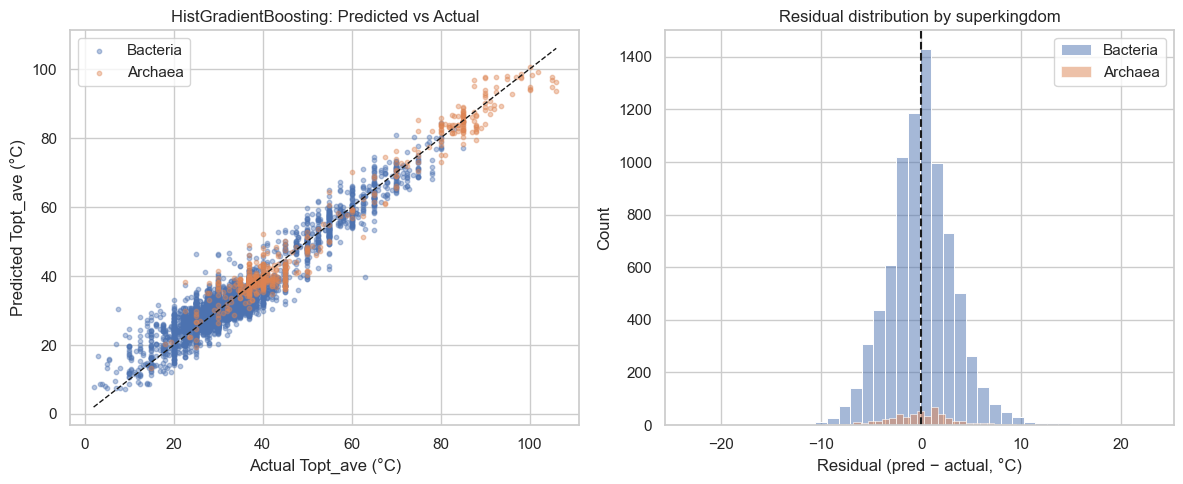

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# (1) 予測 vs 実測
ax = axes[0]
for sk, color in zip(['Bacteria', 'Archaea'], ['#4c72b0', '#dd8452']):
    m = strata == sk
    ax.scatter(y[m], best_pred[m], s=10, alpha=0.4, color=color, label=sk)
lo, hi = y.min(), y.max()
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1)
ax.set_xlabel('Actual Topt_ave (°C)')
ax.set_ylabel('Predicted Topt_ave (°C)')
ax.set_title(f'{best_name}: Predicted vs Actual')
ax.legend()

# (2) 残差ヒストグラム
ax = axes[1]
resid = best_pred - y
for sk, color in zip(['Bacteria', 'Archaea'], ['#4c72b0', '#dd8452']):
    m = strata == sk
    sns.histplot(resid[m], bins=40, ax=ax, color=color, alpha=0.5, label=sk)
ax.axvline(0, color='k', linestyle='--')
ax.set_xlabel('Residual (pred − actual, °C)')
ax.set_title('Residual distribution by superkingdom')
ax.legend()

plt.tight_layout()
plt.show()

## 10. Ridge の係数（解釈性）

Ridge は全データで再学習し、**標準化後**の係数絶対値が大きい特徴量を表示する。

In [12]:
ridge_pipe = models['Ridge']
ridge_pipe.fit(X, y)

# 特徴量名の復元
num_names = NUMERIC_FEATURES
cat_enc = ridge_pipe.named_steps['preprocess'].named_transformers_['cat']['onehot']
cat_names = cat_enc.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
feat_names = num_names + cat_names
coef = ridge_pipe.named_steps['model'].coef_

coef_df = (pd.DataFrame({'feature': feat_names, 'coef': coef})
             .assign(abs_coef=lambda d: d['coef'].abs())
             .sort_values('abs_coef', ascending=False)
             .reset_index(drop=True))
print(f'chosen alpha: {ridge_pipe.named_steps["model"].alpha_}')
coef_df.head(15)

chosen alpha: 10.0


,feature,coef,abs_coef
0,Tmax,5.417486,5.417486
1,Tmin,5.353359,5.353359
2,phylum_grouped_Other,1.492288,1.492288
3,Tmax_Tmin,1.422020,1.422020
4,phylum_grouped_Euryarchaeota,-1.041260,1.041260
5,superkingdom_Bacteria,-0.990524,0.990524
6,superkingdom_Archaea,0.990524,0.990524
7,Genome_GC,-0.875907,0.875907
8,16S_GC,0.738214,0.738214
9,phylum_grouped_Actinobacteria,-0.593184,0.593184


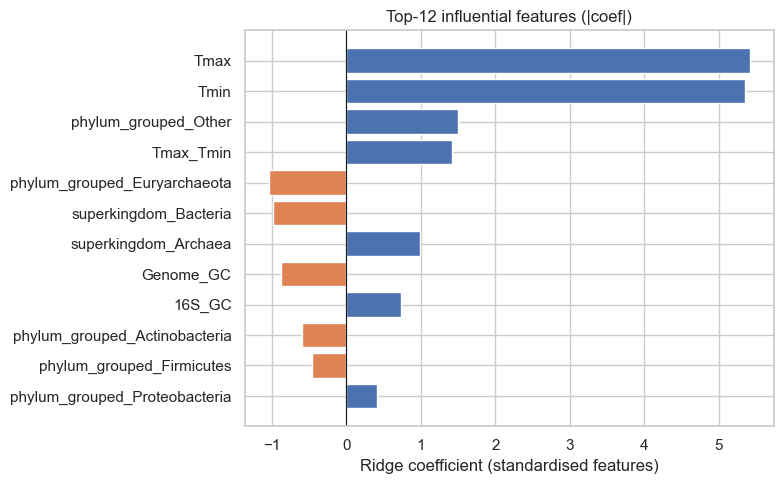

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
top = coef_df.head(12).iloc[::-1]
colors = ['#dd8452' if v < 0 else '#4c72b0' for v in top['coef']]
ax.barh(top['feature'], top['coef'], color=colors)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_xlabel('Ridge coefficient (standardised features)')
ax.set_title('Top-12 influential features (|coef|)')
plt.tight_layout()
plt.show()

## 11. 計画書目標との突合

| 指標 | 目標 | 達成 |
|---|---|---|
| 全体 MAE ≤ 4.0 ℃ | TBD | 上の結果表 §7 を参照 |
| 全体 R² ≥ 0.85 | TBD |  |
| Bacteria MAE ≤ 3.5 ℃ | TBD |  |
| Archaea MAE ≤ 6.0 ℃ | TBD |  |

→ 結果は `docs/modeling_results_ja.md` に清書する。

## 12. 最終モデルの保存（オプション）

モデルを `models/topt_regressor.joblib` として保存する。データの再配布は行わないが、
モデル本体はプロジェクト成果物として保存する。

In [14]:
import os, joblib
os.makedirs('../models', exist_ok=True)
best_pipe = models[best_name]
best_pipe.fit(X, y)
path = f'../models/topt_regressor_{best_name.lower().replace(" ", "_")}.joblib'
joblib.dump(best_pipe, path)
print('saved:', path)

saved: ../models/topt_regressor_histgradientboosting.joblib
